In [1]:
import torch
from transformers import AutoTokenizer, MambaForCausalLM

model_name = "state-spaces/mamba-1.4b-hf"

# 7つのGPUを使用
device_ids = list(range(7))
device = torch.device(f"cuda:{device_ids[0]}")
dtype = torch.float16

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = MambaForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype,
)
model.to(device)
# 7つのGPUで並列化
model = torch.nn.DataParallel(model, device_ids=device_ids)
model.eval()

L = model.module.config.num_hidden_layers  # DataParallel使用時は .module でアクセス
target_layer = L // 2  # 中間
print("num_hidden_layers:", L, "target_layer:", target_layer)
print(f"Using {len(device_ids)} GPUs: {device_ids}")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  8.07i

num_hidden_layers: 48 target_layer: 24
Using 7 GPUs: [0, 1, 2, 3, 4, 5, 6]


In [2]:
from datasets import load_dataset

# 例: Wikitext-103 の train split
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train")

# どれくらい使うか（文書数の上限）
max_docs = 5000   # まずは 2000 行くらいから試す。増やしたければここを上げる
print(ds)

# 空行をスキップしつつバッチを生成するイテレータ
def batch_iter(dataset, batch_size, max_docs=None):
    batch = []
    used = 0
    for i, ex in enumerate(dataset):
        if max_docs is not None and used >= max_docs:
            break
        text = ex["text"].strip()
        if not text:
            continue
        batch.append(text)
        used += 1
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

Dataset({
    features: ['text'],
    num_rows: 1801350
})


In [3]:
from tqdm.auto import tqdm

all_deltas = []

max_length = 1024    # 1 サンプルあたり最大トークン長
batch_size = 32

with torch.no_grad():
    for batch_texts in tqdm(batch_iter(ds, batch_size=batch_size, max_docs=max_docs)):
        enc = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(device)

        out = model(
            **enc,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,  # DataParallelとの互換性のためキャッシュを無効化
        )
        hs = out.hidden_states[target_layer]     # [B, T, d]
        attn = enc["attention_mask"]            # [B, T]

        B, T, D = hs.shape
        for b in range(B):
            valid_len = int(attn[b].sum().item())
            if valid_len <= 1:
                continue
            h_seq = hs[b, :valid_len, :]          # [L, d]
            delta = (h_seq[1:] - h_seq[:-1]).float().cpu()
            all_deltas.append(delta)

delta_big = torch.cat(all_deltas, dim=0)   # [N, d]
print("delta_big:", delta_big.shape)

torch.save(delta_big, "mamba_layer{}_delta.pt".format(target_layer))

157it [26:14, 10.03s/it]


delta_big: torch.Size([484851, 2048])


In [ ]:
# 保存されたデータを読み込む（データを再度取得する必要がない場合）
delta_big = torch.load("mamba_layer{}_delta.pt".format(target_layer))
print("delta_big loaded:", delta_big.shape)


In [17]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, l1_lambda=1e-3):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.l1_lambda = l1_lambda

    def forward(self, x):
        z = F.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z

    def loss(self, x):
        x_hat, z = self.forward(x)
        recon = F.mse_loss(x_hat, x)
        l1 = z.abs().mean()
        return recon + self.l1_lambda * l1, recon.detach(), l1.detach()

# 標準化 + Dataset
x = delta_big    # [N, d]

# 簡単な標準化
mean = x.mean(dim=0, keepdim=True)
std = x.std(dim=0, keepdim=True) + 1e-5
x_norm = (x - mean) / std

input_dim = x_norm.shape[1]
hidden_dim = input_dim * 8   # オーバコンプリート

dataset = TensorDataset(x_norm)
batch_size = 1024
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

sae = SAE(input_dim, hidden_dim, l1_lambda=3e-3).to(device)
# 7つのGPUで並列化
sae = torch.nn.DataParallel(sae, device_ids=device_ids)
optimizer = torch.optim.Adam(sae.module.parameters(), lr=1e-3)  # DataParallel使用時は .module でアクセス

In [18]:
num_epochs = 10   # N, batch_size と相談して調整
log_every = 100

step = 0
for epoch in range(num_epochs):
    for (batch,) in loader:
        batch = batch.to(device)
        loss, recon, l1 = sae.module.loss(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % log_every == 0:
            print(
                f"epoch {epoch} step {step}: "
                f"loss={loss.item():.4e}, "
                f"recon={recon.mean().item():.4e}, "
                f"l1={l1.mean().item():.4e}"
            )
        step += 1

print("training done.")

epoch 0 step 0: loss=1.0370e+00, recon=1.0364e+00, l1=2.2139e-01
epoch 0 step 100: loss=2.4394e-01, recon=2.4325e-01, l1=2.2966e-01
epoch 0 step 200: loss=7.5591e-02, recon=7.4778e-02, l1=2.7091e-01
epoch 0 step 300: loss=4.7423e-02, recon=4.6598e-02, l1=2.7507e-01
epoch 0 step 400: loss=4.3199e-02, recon=4.2378e-02, l1=2.7385e-01
epoch 1 step 500: loss=3.9614e-02, recon=3.8801e-02, l1=2.7091e-01
epoch 1 step 600: loss=4.0245e-02, recon=3.9437e-02, l1=2.6911e-01
epoch 1 step 700: loss=3.9948e-02, recon=3.9155e-02, l1=2.6409e-01
epoch 1 step 800: loss=4.2676e-02, recon=4.1890e-02, l1=2.6192e-01
epoch 1 step 900: loss=3.9044e-02, recon=3.8275e-02, l1=2.5653e-01
epoch 2 step 1000: loss=3.8759e-02, recon=3.7982e-02, l1=2.5881e-01
epoch 2 step 1100: loss=3.8841e-02, recon=3.8081e-02, l1=2.5326e-01
epoch 2 step 1200: loss=4.1195e-02, recon=4.0433e-02, l1=2.5385e-01
epoch 2 step 1300: loss=4.3131e-02, recon=4.2386e-02, l1=2.4812e-01
epoch 2 step 1400: loss=4.3367e-02, recon=4.2622e-02, l1=2.4

In [20]:
sae.eval()
with torch.no_grad():
    _, z_all = sae(x_norm.to(device))
z_all = z_all.cpu()

mean_act = z_all.mean(dim=0)
nonzero_ratio = (z_all > 3e-3).float().mean(dim=0)
global_sparsity = float((z_all > 1e-3).float().mean())

print("global sparsity:", global_sparsity)

OutOfMemoryError: CUDA out of memory. Tried to allocate 29.59 GiB. GPU 0 has a total capacity of 79.11 GiB of which 22.87 GiB is free. Process 1216734 has 56.23 GiB memory in use. Of the allocated memory 21.97 GiB is allocated by PyTorch, and 29.06 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
import os

save_dir = "sae_mamba_layer{}".format(target_layer)
os.makedirs(save_dir, exist_ok=True)

# DataParallel の中身を取り出す
sae_state = sae.module.state_dict()

torch.save(
    {
        "state_dict": sae_state,
        "input_dim": input_dim,
        "hidden_dim": hidden_dim,
        "l1_lambda": sae.module.l1_lambda,
        "mean": mean.cpu(),
        "std": std.cpu(),
        "layer": target_layer,
        "model_name": model_name,
    },
    os.path.join(save_dir, "sae_checkpoint.pt"),
)

print("saved to", os.path.join(save_dir, "sae_checkpoint.pt"))

saved to sae_mamba_layer24/sae_checkpoint.pt


global sparsity: 0.37230783700942993


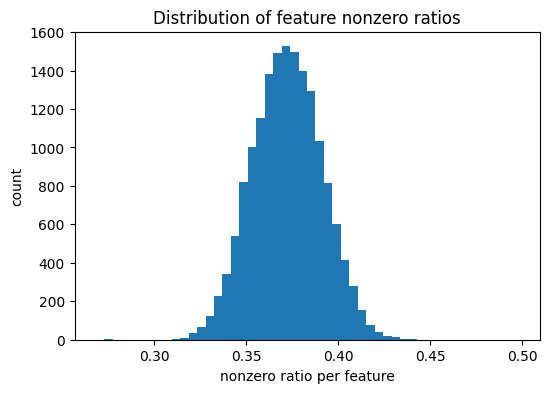

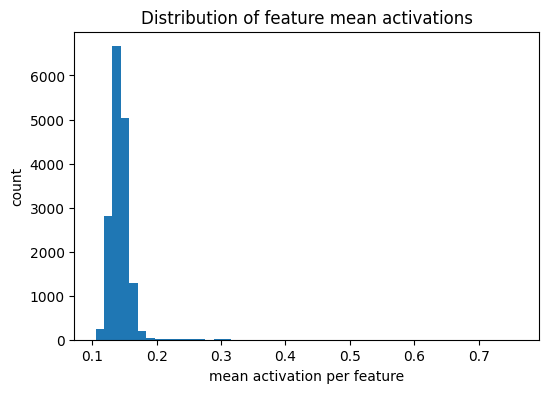

In [12]:
import matplotlib.pyplot as plt

# nonzero_ratio・mean_act はすでに計算済み前提
print("global sparsity:", global_sparsity)

plt.figure(figsize=(6,4))
plt.hist(nonzero_ratio.numpy(), bins=50)
plt.xlabel("nonzero ratio per feature")
plt.ylabel("count")
plt.title("Distribution of feature nonzero ratios")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(mean_act.numpy(), bins=50)
plt.xlabel("mean activation per feature")
plt.ylabel("count")
plt.title("Distribution of feature mean activations")
plt.show()

In [13]:
import numpy as np

nz = nonzero_ratio.numpy()

# もっともスパースな feature 上位/下位を見る
k = 10
sparsest_idx = np.argsort(nz)[:k]
densest_idx  = np.argsort(nz)[-k:]

print("sparsest features:", list(zip(sparsest_idx, nz[sparsest_idx])))
print("densest  features:", list(zip(densest_idx,  nz[densest_idx])))

sparsest features: [(np.int64(14798), np.float32(0.26825562)), (np.int64(6501), np.float32(0.27561045)), (np.int64(3829), np.float32(0.27726042)), (np.int64(13674), np.float32(0.28588578)), (np.int64(11773), np.float32(0.308239)), (np.int64(15502), np.float32(0.30989933)), (np.int64(8609), np.float32(0.31032833)), (np.int64(7151), np.float32(0.31155345)), (np.int64(3361), np.float32(0.31195152)), (np.int64(2622), np.float32(0.312727))]
densest  features: [(np.int64(13434), np.float32(0.43893486)), (np.int64(4345), np.float32(0.43894723)), (np.int64(8410), np.float32(0.43954533)), (np.int64(14926), np.float32(0.4421214)), (np.int64(13059), np.float32(0.44229877)), (np.int64(8905), np.float32(0.44431177)), (np.int64(7824), np.float32(0.4508251)), (np.int64(2254), np.float32(0.4603311)), (np.int64(7796), np.float32(0.4638827)), (np.int64(12673), np.float32(0.49780035))]


In [14]:
# 解析用にそこそこ長いテキストを1つ用意
long_text = " ".join(
    ex["text"].strip()
    for ex in ds.select(range(200))  # 例: 先頭 200 行を連結
    if ex["text"].strip()
)

enc_long = tokenizer(
    long_text,
    return_tensors="pt",
    truncation=True,
    max_length=2048,  # 好きな長さに調整
).to(device)

with torch.no_grad():
    out_long = model(
        **enc_long,
        output_hidden_states=True,
        return_dict=True,
        use_cache=False,
    )
    hs_long = out_long.hidden_states[target_layer][0]  # [T, d]
    T, D = hs_long.shape
    delta_long = (hs_long[1:] - hs_long[:-1]).float()   # [T-1, d]

# SAE に通す前に同じ標準化
delta_long_norm = ((delta_long.cpu() - mean) / std).to(device)

sae.eval()
with torch.no_grad():
    _, z_long = sae(delta_long_norm)   # [T-1, hidden_dim]
z_long = z_long.cpu()

print("z_long shape:", z_long.shape)

z_long shape: torch.Size([2047, 16384])


approx half-life stats (in tokens):
min: 1 median: 1.0 max: 1


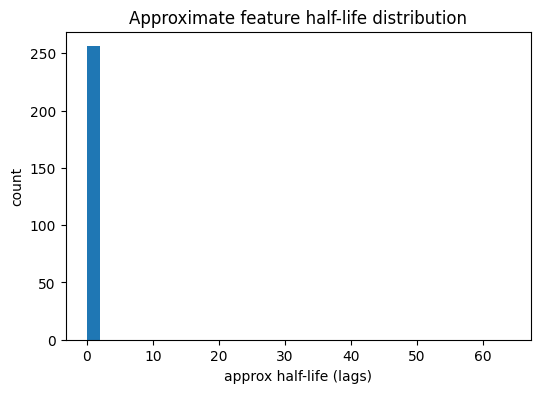

In [15]:
import numpy as np

def autocorr_1d(x, max_lag):
    """
    x: 1D numpy array
    0〜max_lag の自己相関を返す（0ラグは1）
    """
    x = x - x.mean()
    var = np.dot(x, x)
    if var < 1e-12:
        return np.zeros(max_lag+1)
    ac = np.correlate(x, x, mode="full")
    mid = len(ac) // 2
    ac = ac[mid:mid+max_lag+1] / var
    return ac

max_lag = 64  # とりあえず 64 ステップまで

# 計算コストを考えて、feature を少し間引く
num_features = z_long.shape[1]
step_feat = max(1, num_features // 256)  # 多くても 256 個くらい見る
feat_indices = np.arange(0, num_features, step_feat)

taus = []
for i in feat_indices:
    series = z_long[:, i].numpy()
    ac = autocorr_1d(series, max_lag=max_lag)
    # 半減期っぽいラグを探す（ACF が 0.5 を初めて下回るところ）
    below = np.where(ac < 0.5)[0]
    if len(below) == 0:
        tau = max_lag
    else:
        tau = below[0]
    taus.append(tau)

taus = np.array(taus)
print("approx half-life stats (in tokens):")
print("min:", taus.min(), "median:", np.median(taus), "max:", taus.max())

plt.figure(figsize=(6,4))
plt.hist(taus, bins=range(0, max_lag+2, 2))
plt.xlabel("approx half-life (lags)")
plt.ylabel("count")
plt.title("Approximate feature half-life distribution")
plt.show()

In [16]:
feature_id = int(sparsest_idx[0])  # 例: さっき出した一番スパースなやつ

series = z_long[:, feature_id].numpy()
top_k = 10
top_pos = np.argsort(series)[-top_k:][::-1]  # 大きい順

tokens = tokenizer.convert_ids_to_tokens(enc_long["input_ids"][0].tolist())

for rank, pos in enumerate(top_pos, 1):
    # Δstate は t-1→t の更新なので、pos と pos+1 あたりを見ておくとよい
    left = max(0, pos-5)
    right = min(len(tokens)-1, pos+5)
    span = tokens[left:right+1]
    print(f"\n=== rank {rank}, pos {pos}, z={series[pos]:.4f} ===")
    print(" ".join(span))


=== rank 1, pos 1097, z=7.6304 ===
ĠWar Ġ. ĠGall ian ĠArmy ĠSquad Ġ422 Ġ, Ġalso Ġknown Ġas

=== rank 2, pos 1778, z=6.3111 ===
Ġnone Ġother Ġthan Ġthemselves Ġ, Ġthe Ġ422 nd Ġconfront s ĠD

=== rank 3, pos 1383, z=6.1022 ===
Ġorders Ġcause Ġcertain Ġmembers Ġof Ġthe Ġ422 nd Ġgreat Ġdistress Ġ.

=== rank 4, pos 1481, z=5.8159 ===
Ġtraitor Ġwithin Ġtheir Ġranks Ġ, Ġthe Ġ422 nd Ġdesperately Ġmove Ġto

=== rank 5, pos 1247, z=5.0159 ===
Ġher Ġhome Ġ; Ġand ĠNo . 13 ĠR iel a ĠMar

=== rank 6, pos 1198, z=4.5988 ===
Ġthree Ġmain Ġcharacters Ġare ĠNo . 7 ĠKurt ĠIrving Ġ, Ġan

=== rank 7, pos 764, z=4.4439 ===
ĠAction ĠG auge Ġ. ĠUp Ġto Ġnine Ġcharacters Ġcan Ġbe Ġassigned

=== rank 8, pos 189, z=3.8590 ===
Ġ. ĠThe Ġgame Ġbegan Ġdevelopment Ġin Ġ2010 Ġ, Ġcarrying Ġover Ġa

=== rank 9, pos 1839, z=3.6365 ===
ria ĠChronic les ĠII Ġin Ġearly Ġ2010 Ġ, Ġwith Ġfull Ġdevelopment

=== rank 10, pos 386, z=3.6051 ===
s Ġexpanded Ġedition Ġwas Ġreleased Ġin Ġ2014 Ġ. ĠMedia . V
